In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.19.0
Keras version: 3.13.2


In [34]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


(60000, 784) (60000,) (10000, 784) (10000,)


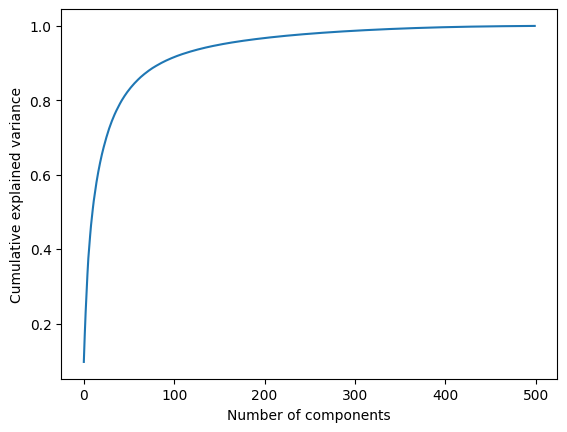

In [35]:
# PCA - priprema podataka i određivanje broja komponenti
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1] * x_train.shape[2]))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1] * x_test.shape[2]))
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

pca = PCA(n_components=500)
pca.fit(x_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [36]:
# PCA - odredjivanje transformacije i transformacija trening i test ulaznih podataka
pca = PCA(n_components=100) # broj komonenenti izabran na bazi prethodnog grafikona
x_pca_train = pca.fit_transform(x_train)
x_pca_test = pca.transform(x_test)
pca_std = np.std(x_pca_train)
print(x_pca_train.shape, x_pca_test.shape)

(60000, 100) (10000, 100)


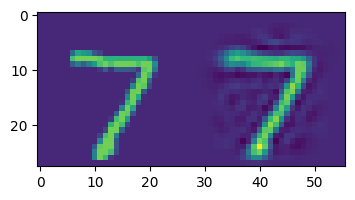

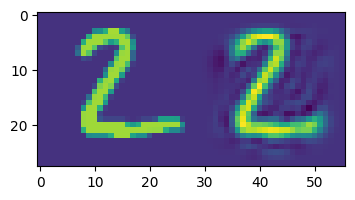

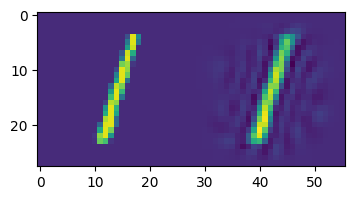

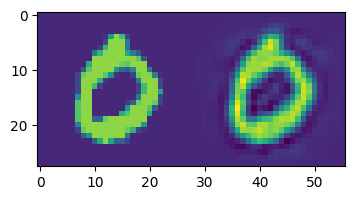

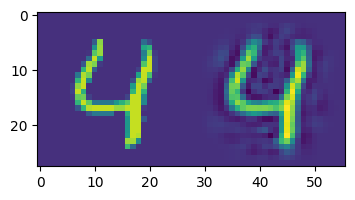

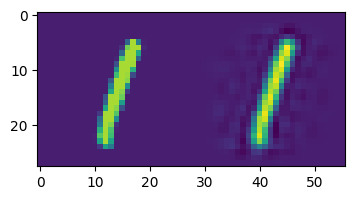

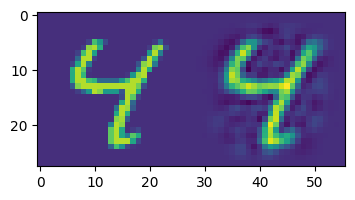

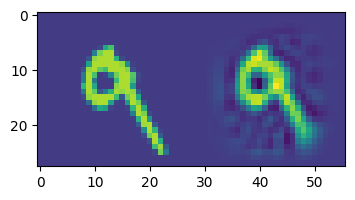

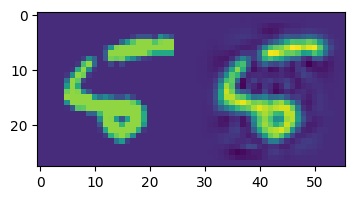

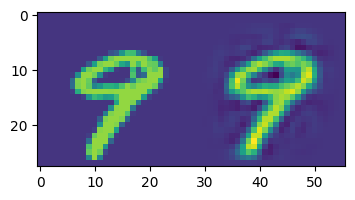

In [37]:
# PCA - validacija (inverzna transformacija)
inv_pca = pca.inverse_transform(x_pca_test)

# Uporedni prikaz originalnih i rekonstruisanih podataka
def side_by_side(indexes):
    org = x_test[indexes].reshape(28, 28)
    rec = inv_pca[indexes].reshape(28, 28)
    pair = np.concatenate((org, rec), axis=1)
    plt.figure(figsize=(4, 2))
    plt.imshow(pair)
    plt.show()

# Uporedni prikaz 10 slika u cilju validacije broja komponenti
for index in range(0, 10):
    side_by_side(index)

In [38]:
# Kreiranje MLP modela
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.InputLayer((x_pca_train.shape[1],)))
model.add(tf.keras.layers.Dense(256, activation='tanh'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-1),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Treniranje modela
hist = model.fit(x_pca_train, y_train, batch_size=2048, epochs=500, validation_data=(x_pca_test, y_test), verbose=2)

Epoch 1/500
30/30 - 3s - 89ms/step - loss: 1.1991 - sparse_categorical_accuracy: 0.6614 - val_loss: 0.6901 - val_sparse_categorical_accuracy: 0.8276
Epoch 2/500
30/30 - 0s - 5ms/step - loss: 0.6151 - sparse_categorical_accuracy: 0.8425 - val_loss: 0.5158 - val_sparse_categorical_accuracy: 0.8669
Epoch 3/500
30/30 - 0s - 5ms/step - loss: 0.5026 - sparse_categorical_accuracy: 0.8668 - val_loss: 0.4473 - val_sparse_categorical_accuracy: 0.8786
Epoch 4/500
30/30 - 0s - 5ms/step - loss: 0.4499 - sparse_categorical_accuracy: 0.8776 - val_loss: 0.4094 - val_sparse_categorical_accuracy: 0.8875
Epoch 5/500
30/30 - 0s - 6ms/step - loss: 0.4181 - sparse_categorical_accuracy: 0.8841 - val_loss: 0.3852 - val_sparse_categorical_accuracy: 0.8937
Epoch 6/500
30/30 - 0s - 6ms/step - loss: 0.3964 - sparse_categorical_accuracy: 0.8895 - val_loss: 0.3678 - val_sparse_categorical_accuracy: 0.8967
Epoch 7/500
30/30 - 0s - 5ms/step - loss: 0.3804 - sparse_categorical_accuracy: 0.8932 - val_loss: 0.3547 - val

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0745 - sparse_categorical_accuracy: 0.9778
[0.07445511966943741, 0.9778000116348267]


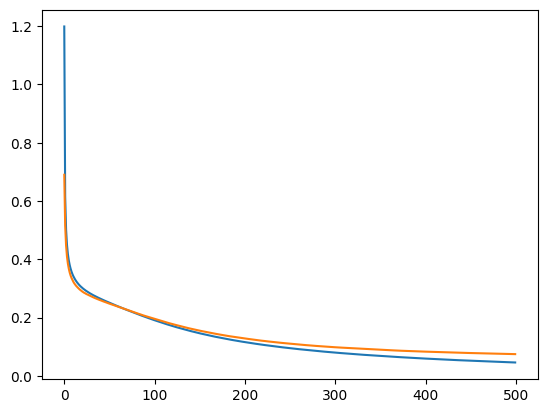

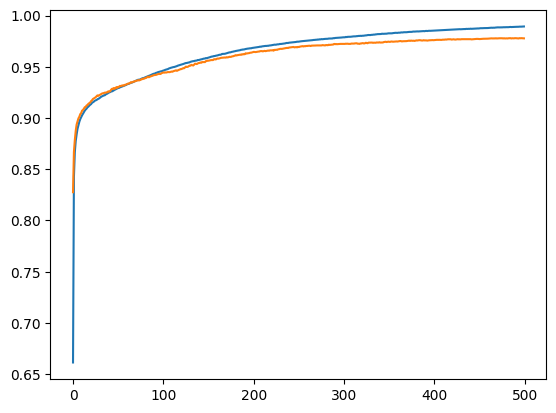

In [40]:
# Evaluacija i prikaz grafikona
res = model.evaluate(x_pca_test, y_test, batch_size=256)
print(res)

plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.show()

plt.clf()
plt.plot(hist.history['sparse_categorical_accuracy'])
plt.plot(hist.history['val_sparse_categorical_accuracy'])
plt.show()